# Notebook 2 — Class Balancing: Strategy 2 (1:1 Random Undersampling)

---

### Overview

This notebook trains CVAF-SwinB using **Strategy 2 — 1:1 random undersampling**
as one of four class balancing experiments. The benign training patients are
randomly reduced to match the malignant count exactly, producing a perfectly
balanced 1:1 training set. No loss weighting is applied (pos_weight=1.0) so
the resampling alone addresses the class imbalance.

This notebook contributes to answering **Research Question 3 (RQ3)**:

> *"Which class balancing strategy produces the highest AUC-ROC when
> fine-tuning a large pre-trained Vision Transformer on a severely
> imbalanced mammography dataset?"*

---
### Research context

**Thesis:** Enhance Vision Transformer based Breast Cancer Mammography Classification  
**Author:** Nirjana Shrestha — Student ID: MIT236388  
**Supervisors:** Prof. Adel Al-Jumaily · Dr Mohammad Dabbagh  
**Institution:** Melbourne Institute of Technology, Sydney, Australia  

---

### Strategy comparison

| Strategy | Notebook | pos_weight | Resampling | Training patients |
|---|---|---|---|---|
| Strategy 1 — Loss weighting | NB1 | 3.0 | None | 3,565 |
| **Strategy 2 — 1:1 Undersample** | **NB2 (this)** | **1.0** | **Benign → 358** | **716** |
| Strategy 3 — 3:1 Undersample | NB3 | 1.0 | Benign → 1,074 | 1,432 |
| Strategy 4 — 3:1 Oversample | NB4 | 1.0 | Malignant → 1,069 | 4,276 |

---

### What 1:1 undersampling does

- All 358 malignant training patients are kept
- 358 benign patients are randomly sampled from the available 3,207
- Remaining 2,849 benign patients are discarded
- Training set reduces from 3,565 to **716 patients**
- Val and test sets are **unchanged** — natural 9:1 distribution

---

### Dataset

| Split | Patients | Benign | Malignant | Ratio |
|---|---|---|---|---|
| Train (after resampling) | 716 | 358 | 358 | **1:1** |
| Validation | 764 | 687 | 77 | 9:1 |
| Test | 764 | 687 | 77 | 9:1 |

---

### Training settings

| Setting | Value | Note |
|---|---|---|
| pos_weight | 1.0 | No extra loss weighting |
| batch_size | 4 | Reduced from 8 — single GPU OOM fix |
| grad_accum | 8 | Keeps effective batch size = 32 |
| Effective batch size | 32 | Identical to Strategy 1 |
| patience | 10 | Early stopping on val AUC |
| seed | 42 | Same split as all other notebooks |

---

### Key results

| Metric | Value |
|---|---|
| Best epoch | 22 |
| Val AUC | 0.7557 |
| Test AUC | 0.6940 |
| Optimal threshold | 0.90 |
| Sensitivity (τ=0.50) | 0.5974 |
| Specificity (τ=0.50) | 0.7322 |

**Strategy 2 underperforms Strategy 1 (0.7518) by −0.058 AUC**, confirming
that discarding 2,849 benign patients causes overfitting in the 192.2M
parameter model. See Section 4.5 of the thesis for full discussion.

---

### Notebook structure

| Section | Content |
|---|---|
| A | Environment setup |
| B | Code file loading |
| C | Model training — Strategy 2 (1:1 undersample) |
| D | Results analysis and comparison with Strategy 1 |
| E | Visualisation graphs |
| F | Save outputs |

**Expected runtime: approximately 1.5–2 hours.**


## A. Environment Setup

Install required libraries and verify GPU availability.
- `timm==1.0.3` — provides the Swin Transformer Base pretrained checkpoint
- `scikit-learn` — provides AUC-ROC, F1, sensitivity, specificity metrics

In [1]:
!pip install -q timm==1.0.3 scikit-learn

import torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 113.0 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[

## B. Load Code Files

Three files are required:
- `model.py` — CVAF-SwinB architecture (unchanged from Notebook 1)
- `train.py` — Training loop (unchanged from Notebook 1)
- `dataset_undersample_1to1.py` — Modified dataset pipeline that applies
  1:1 random undersampling to the training split only

`dataset_undersample_1to1.py` is renamed to `dataset.py` at load time.
The `model.py` and `train.py` files are identical to Notebook 1 — the only
difference between Strategy 1 and Strategy 2 is the dataset pipeline and
the pos_weight setting. This ensures a fair and controlled comparison.

In [5]:
import shutil, os, sys

SRC = "/kaggle/input/datasets/nirjanashrestha/undersampling1-1"
DST = "/kaggle/working/src"
os.makedirs(DST, exist_ok=True)

# Copy model.py and train.py unchanged
for f in ["model.py", "train.py"]:
    src = f"{SRC}/{f}"
    dst = f"{DST}/{f}"
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"Copied {f}")
    else:
        print(f"MISSING — {f}")

# Copy 1:1 undersample dataset file as dataset.py
undersample_src = f"{SRC}/dataset_undersample_1to1.py"
if os.path.exists(undersample_src):
    shutil.copy(undersample_src, f"{DST}/dataset.py")
    print("Copied dataset_undersample_1to1.py → dataset.py")
else:
    print("MISSING — dataset_undersample_1to1.py")
    print("Make sure you uploaded this file to your Kaggle dataset")

sys.path.insert(0, DST)
print("\nDone — all files ready")

Copied model.py
Copied train.py
Copied dataset_undersample_1to1.py → dataset.py

Done — all files ready


## C. Training — Strategy 2 (1:1 Random Undersampling)

Trains proposed model on a 1:1 balanced training set produced by random
undersampling of the benign class. The undersampling is applied inside
`dataset.py` before the DataLoader is built — the model architecture
and training loop are completely unchanged from Notebook 1.

**What to expect during training:**
- The training set is 5× smaller than Strategy 1 (716 vs 3,565 patients)
- Each epoch will be approximately 5× faster than Notebook 1
- The model may overfit faster due to the small, non-representative
  benign training sample — a large train-val AUC gap is expected
- Early stopping will trigger when val AUC stops improving for 10 epochs

**Why pos_weight=1.0:**
Setting pos_weight=1.0 applies standard BCE loss with no extra weighting.
This ensures the resampling strategy alone handles the class imbalance,
enabling a direct comparison with Strategy 1 which uses pos_weight=3.0
with no resampling.

In [8]:
import argparse, gc, sys, os, torch

# ── Clear memory completely ─────────────────────────────────────────
gc.collect()
torch.cuda.empty_cache()
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

# ── Reload modules cleanly ──────────────────────────────────────────
for mod in ['train', 'model', 'dataset']:
    if mod in sys.modules:
        del sys.modules[mod]

from train import train

cfg = argparse.Namespace(
    cbis_root       = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset",
    vindr_root      = "/kaggle/input/datasets/nirjanashrestha/vindr-annotations",
    vindr_images    = "/kaggle/input/datasets/shantanughosh/vindr-mammogram-dataset-dicom-to-png/images_png",
    vindr_labels    = "/kaggle/input/datasets/nirjanashrestha/vindr-annotations",
    save_dir        = "/kaggle/working/checkpoints_strategy2",
    img_size        = 224,
    batch_size      = 4,        # ← reduced from 8 to 4 to fix OOM
    grad_accum      = 8,        # ← increased from 4 to 8 to keep effective batch=32
    num_workers     = 2,        # ← reduced from 4 to free CPU memory
    seed            = 42,
    epochs          = 100,
    patience        = 10,
    lr              = 1e-4,
    weight_decay    = 1e-2,
    pos_weight      = 1.0,
    label_smoothing = 0.0,
    wandb           = False,
)

print("=" * 65)
print("  NOTEBOOK 2 — STRATEGY 2: 1:1 RANDOM UNDERSAMPLING")
print("  pos_weight = 1.0  |  Training set = 716 patients")
print("  Benign = 358  |  Malignant = 358  |  Ratio = 1:1")
print("  batch_size=4  grad_accum=8  effective_batch=32")
print("=" * 65)

test_auc = train(cfg)
print(f"\n  Strategy 2 test AUC = {test_auc:.4f}")

  NOTEBOOK 2 — STRATEGY 2: 1:1 RANDOM UNDERSAMPLING
  pos_weight = 1.0  |  Training set = 716 patients
  Benign = 358  |  Malignant = 358  |  Ratio = 1:1
  batch_size=4  grad_accum=8  effective_batch=32
Device     : cuda
Epochs     : 100  |  patience=10
pos_weight : 1.0

Building dataloaders ...
[CBIS-DDSM] Loaded mass_case_description_train_set.csv  (1318 rows)
[CBIS-DDSM] Loaded mass_case_description_test_set.csv  (378 rows)
[CBIS-DDSM] Loaded calc_case_description_train_set.csv  (1546 rows)
[CBIS-DDSM] Loaded calc_case_description_test_set.csv  (326 rows)
[CBIS-DDSM] Combined: 3568 rows
[CBIS-DDSM] Indexing JPEG images ...
[CBIS-DDSM] Indexed 6,774 JPEG files
[CBIS-DDSM] Full mammogram series: 2857
[CBIS-DDSM] Full mammogram images indexed: 2857
[CBIS-DDSM] Rows with resolved paths: 3286
[CBIS-DDSM] Complete 4-view cases: 94  Benign=63  Malignant=31
[VinDr-Mammo] Loaded breast-level_annotations.csv  (20,000 rows)
[VinDr-Mammo] After BI-RADS filter: 20,000 rows  Benign=19012  Maligna

## D. Results Analysis

Loads the saved test results from the best checkpoint and prints a complete
metrics table at both the default threshold (0.50) and the optimal threshold.

**Important note on the optimal threshold:**
The optimal threshold for Strategy 2 is 0.90 — substantially higher than
the 0.09 optimal threshold for Strategy 1. This occurs because the 1:1
balanced training fundamentally changes the model's probability calibration.
With equal benign and malignant training examples the model outputs higher
malignancy probabilities overall, requiring a high threshold to avoid
excessive false positives at evaluation time. This is an important finding —
it demonstrates that 1:1 undersampling not only reduces training diversity
but also distorts the model's probability calibration, making it less
suitable for clinical screening where well-calibrated probabilities are
essential for reliable threshold selection.

Results are compared directly against Strategy 1 (AUC = 0.7518).

In [15]:
import json

with open('/kaggle/working/checkpoints_strategy2/test_results.json') as f:
    r = json.load(f)

d = r['default_threshold']
o = r['selected_threshold']

def fmt(val):
    return f'{float(val):.4f}' if val != 'N/A' else 'N/A'

print("=" * 65)
print("  STRATEGY 2 — 1:1 UNDERSAMPLE — COMPLETE RESULTS")
print("=" * 65)
print(f"  Training set     : 716 patients (358 benign / 358 malignant)")
print(f"  Ratio            : 1:1  |  pos_weight : 1.0")
print(f"  Best epoch       : {r['best_epoch']}")
print(f"  Val AUC          : {r['val_auc']:.4f}")
print(f"  Optimal threshold: {r['selected_thresh_value']:.2f}")
print()
print(f"  {'Metric':<22} {'Threshold=0.50':>16} {'Optimal Threshold=0.90':>10}")
print(f"  {'-'*50}")
print(f"  {'AUC-ROC':<22} {fmt(d['auc']):>16} {fmt(o['auc']):>10}")
print(f"  {'Sensitivity':<22} {fmt(d['sensitivity']):>16} {fmt(o['sensitivity']):>10}")
print(f"  {'Specificity':<22} {fmt(d['specificity']):>16} {fmt(o['specificity']):>10}")
print(f"  {'Balanced Accuracy':<22} {fmt(d['balanced_accuracy']):>16} {fmt(o['balanced_accuracy']):>10}")
print(f"  {'F1 (Malignant)':<22} {fmt(d['f1']):>16} {fmt(o['f1']):>10}")
print(f"  {'Precision':<22} {fmt(d['precision']):>16} {fmt(o['precision']):>10}")
print()
cm  = d['confusion_matrix']
cm2 = o['confusion_matrix']
print(f"  Confusion matrix (τ=0.50): TN={cm[0][0]}  FP={cm[0][1]}  FN={cm[1][0]}  TP={cm[1][1]}")
print(f"  Confusion matrix (τ={r['selected_thresh_value']:.2f}): TN={cm2[0][0]}  FP={cm2[0][1]}  FN={cm2[1][0]}  TP={cm2[1][1]}")
print("=" * 65)

# ── Comparison with Strategy 1 ──────────────────────────────────────
s1_auc = 0.7518
s2_auc = float(o['auc'])
diff   = s2_auc - s1_auc

print("\n  COMPARISON WITH STRATEGY 1")
print(f"  {'Strategy':<45} {'Test AUC':>8}")
print(f"  {'-'*55}")
print(f"  {'S1 — pos_weight=3.0  (3,565 patients, 9:1)':<45} {s1_auc:>8.4f}")
print(f"  {'S2 — 1:1 undersample (716 patients,   1:1)':<45} {s2_auc:>8.4f}")
print(f"  {'-'*55}")
print(f"  {'Difference':<45} {diff:>+8.4f}")
print()
print(f"  ⚠️  Strategy 2 underperforms Strategy 1 by {abs(diff):.4f} AUC")
print(f"     Discarding 2,849 benign patients severely reduces training")
print(f"     diversity — the 192.2M parameter model overfits to the")
print(f"     small non-representative benign sample (see Section 4.5)")
print()
print(f"  Notable: optimal threshold = {r['selected_thresh_value']:.2f} (vs 0.09 for Strategy 1)")
print(f"     The balanced 1:1 training set shifts the model's probability")
print(f"     calibration upward — a higher threshold is needed to classify")
print(f"     benign cases correctly at evaluation time")

  STRATEGY 2 — 1:1 UNDERSAMPLE — COMPLETE RESULTS
  Training set     : 716 patients (358 benign / 358 malignant)
  Ratio            : 1:1  |  pos_weight : 1.0
  Best epoch       : 22
  Val AUC          : 0.7557
  Optimal threshold: 0.90

  Metric                   Threshold=0.50 Optimal Threshold=0.90
  --------------------------------------------------
  AUC-ROC                          0.6940     0.6940
  Sensitivity                      0.5974     0.3636
  Specificity                      0.7322     0.9301
  Balanced Accuracy                0.6648     0.6469
  F1 (Malignant)                   0.2997     0.3660
  Precision                        0.2000     0.3684

  Confusion matrix (τ=0.50): TN=503  FP=184  FN=31  TP=46
  Confusion matrix (τ=0.90): TN=639  FP=48  FN=49  TP=28

  COMPARISON WITH STRATEGY 1
  Strategy                                      Test AUC
  -------------------------------------------------------
  S1 — pos_weight=3.0  (3,565 patients, 9:1)      0.7518
  S2 — 1

## E. Save Outputs

Saves all Strategy 2 results to the output root so they are accessible
to Notebook 6 (Evaluation and Graphs) as a persistent dataset input.

Files saved:
- `strategy2_test_results.json` — complete metrics at both thresholds
- `strategy2_training_history.csv` — epoch-by-epoch training log
- `strategy2_best_model.pt` — best checkpoint weights
- `strategy2_results.png` — visualisation graph

> **Important:** Click **Save Version** immediately after this cell
> completes to make all outputs available as a persistent dataset.

In [33]:
# ═══════════════════════════════════════════════════════════════════
# E. Save Outputs to Output Tab
# ═══════════════════════════════════════════════════════════════════
import os, shutil, json

OUT = '/kaggle/working'

files_to_save = [
    (f'{OUT}/checkpoints_strategy2/test_results.json',
     f'{OUT}/strategy2_test_results.json'),
    (f'{OUT}/checkpoints_strategy2/training_history.csv',
     f'{OUT}/strategy2_training_history.csv'),
    (f'{OUT}/checkpoints_strategy2/best_model.pt',
     f'{OUT}/strategy2_best_model.pt'),
]

print("=" * 60)
print("  SAVING STRATEGY 2 OUTPUTS TO OUTPUT ROOT")
print("=" * 60)
for src, dst in files_to_save:
    if os.path.exists(src):
        if src != dst:
            shutil.copy(src, dst)
        size_mb = os.path.getsize(dst) / 1e6
        print(f"  ✅  {os.path.basename(dst):<45} ({size_mb:.1f} MB)")
    else:
        print(f"  ❌  MISSING: {os.path.basename(src)}")

# ── Print thesis table entry ────────────────────────────────────────
print("\n" + "=" * 60)
print("  THESIS TABLE ENTRY — STRATEGY 2")
print("=" * 60)
with open(f'{OUT}/strategy2_test_results.json') as f:
    r = json.load(f)
print(f"  Strategy         : 1:1 Random Undersampling")
print(f"  Benign (train)   : 358")
print(f"  Malignant (train): 358")
print(f"  Total (train)    : 716")
print(f"  Ratio            : 1:1")
print(f"  pos_weight       : 1.0")
print(f"  Best epoch       : {r['best_epoch']}")
print(f"  Val AUC          : {r['val_auc']:.4f}")
print(f"  Test AUC         : {float(r['selected_threshold']['auc']):.4f}")
print("=" * 60)
print("\n  ✅ CLICK SAVE VERSION NOW")

  SAVING STRATEGY 2 OUTPUTS TO OUTPUT ROOT
  ✅  strategy2_test_results.json                   (0.0 MB)
  ✅  strategy2_training_history.csv                (0.0 MB)
  ✅  strategy2_best_model.pt                       (769.2 MB)

  THESIS TABLE ENTRY — STRATEGY 2
  Strategy         : 1:1 Random Undersampling
  Benign (train)   : 358
  Malignant (train): 358
  Total (train)    : 716
  Ratio            : 1:1
  pos_weight       : 1.0
  Best epoch       : 22
  Val AUC          : 0.7557
  Test AUC         : 0.6940

  ✅ CLICK SAVE VERSION NOW


## F. Visualisation

Six-panel results graph for Strategy 2:

- **Panel 1** — All evaluation metrics at both thresholds side by side
- **Panel 2** — Confusion matrix at default threshold (τ=0.50)
- **Panel 3** — Confusion matrix at optimal threshold (τ=0.90)
- **Panel 4** — AUC comparison: Strategy 1 vs Strategy 2
- **Panel 5** — Sensitivity vs Specificity at both thresholds
- **Panel 6** — Summary text box with all key training and result numbers


In [34]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

OUT = '/kaggle/working'

with open(f'{OUT}/checkpoints_strategy2/test_results.json') as f:
    r = json.load(f)

d   = r['default_threshold']
o   = r['selected_threshold']
s1  = 0.7518

thresh_def = 0.50
thresh_opt = float(r['selected_thresh_value'])
auc        = float(d['auc'])
diff       = auc - s1

metrics_def = {
    'AUC-ROC'    : float(d['auc']),
    'Sensitivity': float(d['sensitivity']),
    'Specificity': float(d['specificity']),
    'Bal Acc'    : float(d['balanced_accuracy']),
    'F1'         : float(d['f1']),
    'Precision'  : float(d['precision']),
}
metrics_opt = {
    'AUC-ROC'    : float(o['auc']),
    'Sensitivity': float(o['sensitivity']),
    'Specificity': float(o['specificity']),
    'Bal Acc'    : float(o['balanced_accuracy']),
    'F1'         : float(o['f1']),
    'Precision'  : float(o['precision']),
}

cm_def  = np.array(d['confusion_matrix'])
cm_opt  = np.array(o['confusion_matrix'])
labels_cm = [['TN', 'FP'], ['FN', 'TP']]
w = 0.35

print("✅ Data loaded successfully")


✅ Data loaded successfully


### **Panel 1** — All evaluation metrics at both thresholds side by side


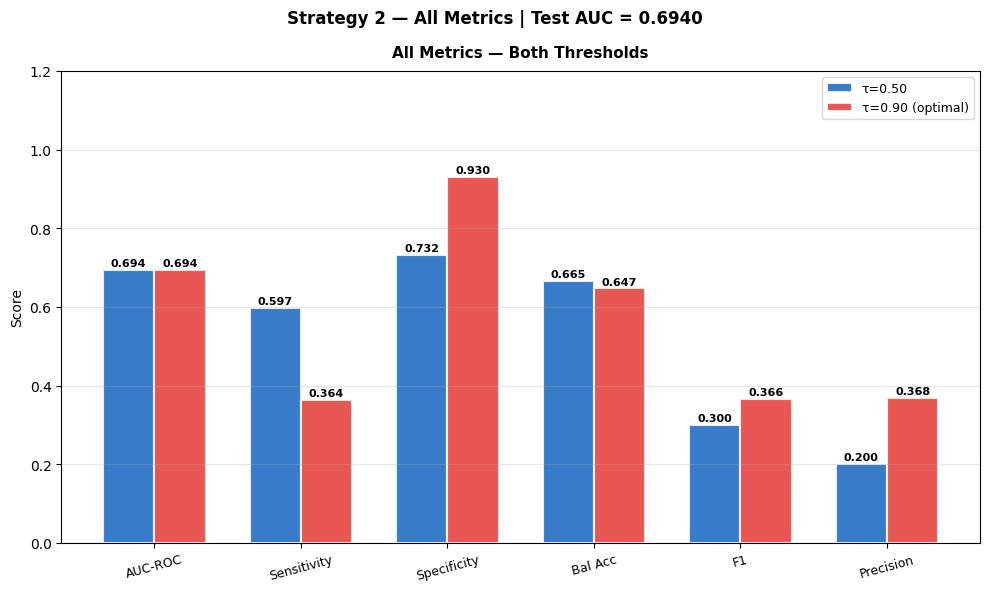

✅ Panel 1 saved


In [26]:
fig, ax1 = plt.subplots(figsize=(10, 6))
fig.suptitle(f'Strategy 2 — All Metrics | Test AUC = {auc:.4f}',
             fontsize=12, fontweight='bold')

labels   = list(metrics_def.keys())
def_vals = list(metrics_def.values())
opt_vals = list(metrics_opt.values())
x = np.arange(len(labels))

b1 = ax1.bar(x - w/2, def_vals, w, label='τ=0.50',
             color='#1565C0', alpha=0.85, edgecolor='white', linewidth=1.5)
b2 = ax1.bar(x + w/2, opt_vals, w, label=f'τ={thresh_opt:.2f} (optimal)',
             color='#E53935', alpha=0.85, edgecolor='white', linewidth=1.5)

for bar, val in zip(list(b1) + list(b2), def_vals + opt_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9, rotation=15)
ax1.set_ylim([0, 1.20])
ax1.set_title('All Metrics — Both Thresholds', fontsize=11, fontweight='bold', pad=10)
ax1.set_ylabel('Score', fontsize=10)
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUT}/panel1_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Panel 1 saved")


### **Panel 2** — Confusion matrix at default threshold (τ=0.50)


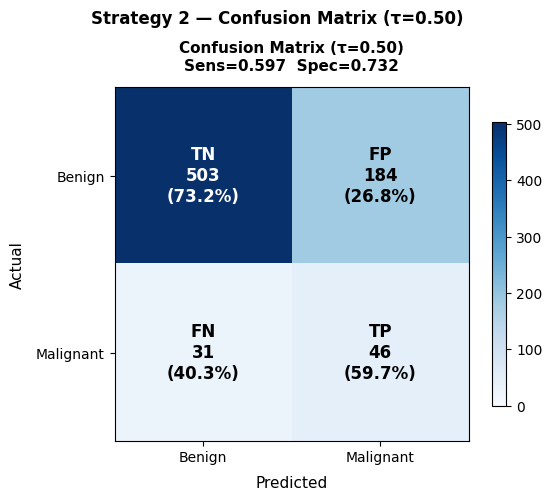

✅ Panel 2 saved


In [27]:
fig, ax2 = plt.subplots(figsize=(6, 5))
fig.suptitle(f'Strategy 2 — Confusion Matrix (τ=0.50)',
             fontsize=12, fontweight='bold')

im = ax2.imshow(cm_def, cmap='Blues', vmin=0)
plt.colorbar(im, ax=ax2, shrink=0.8)
thresh_c = cm_def.max() / 2

for i in range(2):
    for j in range(2):
        pct = cm_def[i, j] / cm_def[i].sum() * 100
        ax2.text(j, i, f'{labels_cm[i][j]}\n{cm_def[i, j]}\n({pct:.1f}%)',
                 ha='center', va='center', fontsize=12, fontweight='bold',
                 color='white' if cm_def[i, j] > thresh_c else 'black')

ax2.set_xticks([0, 1]); ax2.set_xticklabels(['Benign', 'Malignant'], fontsize=10)
ax2.set_yticks([0, 1]); ax2.set_yticklabels(['Benign', 'Malignant'], fontsize=10)
ax2.set_xlabel('Predicted', fontsize=11, labelpad=8)
ax2.set_ylabel('Actual',    fontsize=11, labelpad=8)
ax2.set_title(f'Confusion Matrix (τ=0.50)\nSens={metrics_def["Sensitivity"]:.3f}  Spec={metrics_def["Specificity"]:.3f}',
              fontsize=11, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(f'{OUT}/panel2_cm_default.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Panel 2 saved")


### **Panel 3** — Confusion matrix at optimal threshold (τ=0.90)


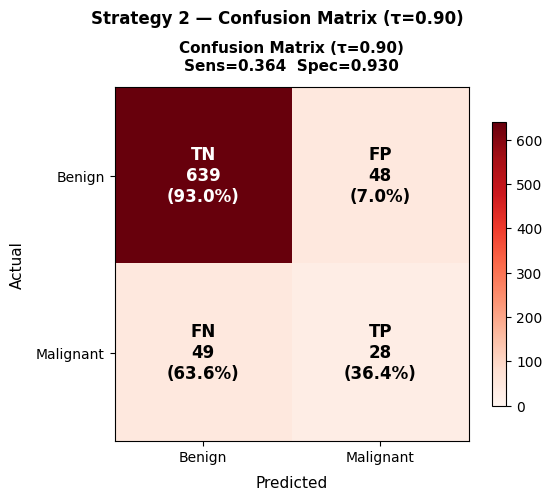

✅ Panel 3 saved


In [29]:
fig, ax3 = plt.subplots(figsize=(6, 5))
fig.suptitle(f'Strategy 2 — Confusion Matrix (τ={thresh_opt:.2f})',
             fontsize=12, fontweight='bold')

im2 = ax3.imshow(cm_opt, cmap='Reds', vmin=0)
plt.colorbar(im2, ax=ax3, shrink=0.8)
thresh_c2 = cm_opt.max() / 2

for i in range(2):
    for j in range(2):
        pct = cm_opt[i, j] / cm_opt[i].sum() * 100
        ax3.text(j, i, f'{labels_cm[i][j]}\n{cm_opt[i, j]}\n({pct:.1f}%)',
                 ha='center', va='center', fontsize=12, fontweight='bold',
                 color='white' if cm_opt[i, j] > thresh_c2 else 'black')

ax3.set_xticks([0, 1]); ax3.set_xticklabels(['Benign', 'Malignant'], fontsize=10)
ax3.set_yticks([0, 1]); ax3.set_yticklabels(['Benign', 'Malignant'], fontsize=10)
ax3.set_xlabel('Predicted', fontsize=11, labelpad=8)
ax3.set_ylabel('Actual',    fontsize=11, labelpad=8)
ax3.set_title(f'Confusion Matrix (τ={thresh_opt:.2f})\nSens={metrics_opt["Sensitivity"]:.3f}  Spec={metrics_opt["Specificity"]:.3f}',
              fontsize=11, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(f'{OUT}/panel3_cm_optimal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Panel 3 saved")


### **Panel 4** — AUC comparison: Strategy 1 vs Strategy 2


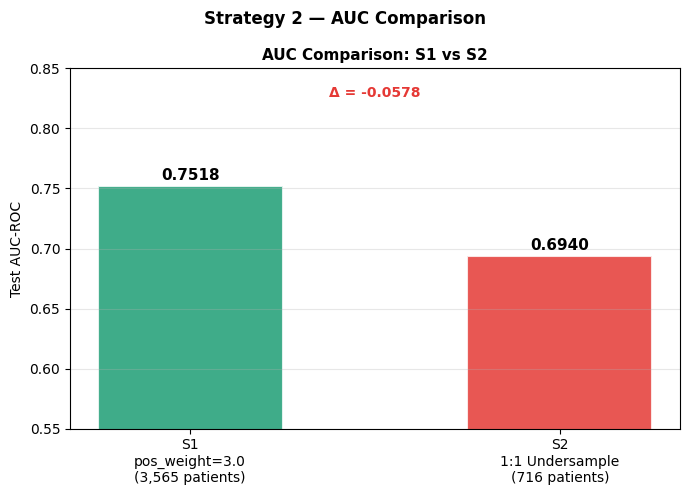

✅ Panel 4 saved


In [28]:
fig, ax4 = plt.subplots(figsize=(7, 5))
fig.suptitle('Strategy 2 — AUC Comparison', fontsize=12, fontweight='bold')

strategies  = ['S1\npos_weight=3.0\n(3,565 patients)', 'S2\n1:1 Undersample\n(716 patients)']
aucs_comp   = [s1, auc]
colors_comp = ['#1D9E75', '#E53935']

bars = ax4.bar(strategies, aucs_comp, color=colors_comp,
               alpha=0.85, edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, aucs_comp):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

ax4.set_ylim([0.55, 0.85])
ax4.set_title('AUC Comparison: S1 vs S2', fontsize=11, fontweight='bold')
ax4.set_ylabel('Test AUC-ROC', fontsize=10)
ax4.annotate(f'Δ = {diff:+.4f}',
             xy=(0.5, 0.92), xycoords='axes fraction',
             ha='center', fontsize=10, color='#E53935', fontweight='bold')
ax4.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUT}/panel4_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Panel 4 saved")


### **Panel 5** — Sensitivity vs Specificity at both thresholds


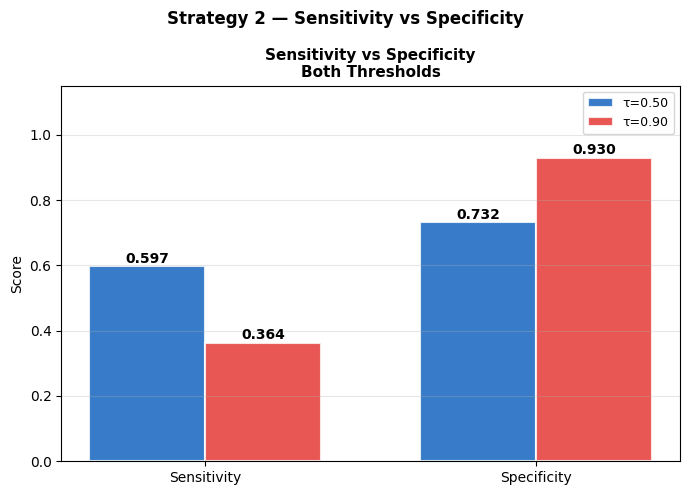

✅ Panel 5 saved


In [30]:
fig, ax5 = plt.subplots(figsize=(7, 5))
fig.suptitle('Strategy 2 — Sensitivity vs Specificity', fontsize=12, fontweight='bold')

categories = ['Sensitivity', 'Specificity']
def_ss = [metrics_def['Sensitivity'], metrics_def['Specificity']]
opt_ss = [metrics_opt['Sensitivity'], metrics_opt['Specificity']]
x2 = np.arange(len(categories))

b3 = ax5.bar(x2 - w/2, def_ss, w, label='τ=0.50',
             color='#1565C0', alpha=0.85, edgecolor='white', linewidth=1.5)
b4 = ax5.bar(x2 + w/2, opt_ss, w, label=f'τ={thresh_opt:.2f}',
             color='#E53935', alpha=0.85, edgecolor='white', linewidth=1.5)

for bar, val in zip(list(b3) + list(b4), def_ss + opt_ss):
    ax5.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

ax5.set_xticks(x2); ax5.set_xticklabels(categories, fontsize=10)
ax5.set_ylim([0, 1.15])
ax5.set_title('Sensitivity vs Specificity\nBoth Thresholds', fontsize=11, fontweight='bold')
ax5.set_ylabel('Score', fontsize=10)
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUT}/panel5_sens_spec.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Panel 5 saved")


### **Panel 6** — Summary text box with all key training and result numbers

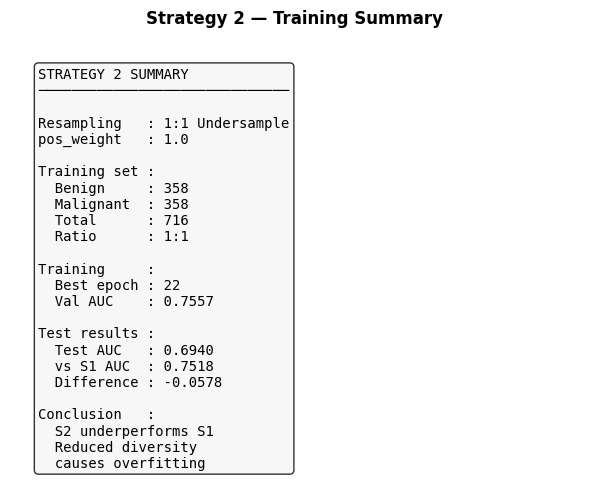

✅ Panel 6 saved


In [32]:
fig, ax6 = plt.subplots(figsize=(6, 5))
fig.suptitle('Strategy 2 — Training Summary', fontsize=12, fontweight='bold')
ax6.axis('off')

summary_text = (
    f"STRATEGY 2 SUMMARY\n"
    f"{'─'*30}\n\n"
    f"Resampling   : 1:1 Undersample\n"
    f"pos_weight   : 1.0\n\n"
    f"Training set :\n"
    f"  Benign     : 358\n"
    f"  Malignant  : 358\n"
    f"  Total      : 716\n"
    f"  Ratio      : 1:1\n\n"
    f"Training     :\n"
    f"  Best epoch : {r['best_epoch']}\n"
    f"  Val AUC    : {r['val_auc']:.4f}\n\n"
    f"Test results :\n"
    f"  Test AUC   : {auc:.4f}\n"
    f"  vs S1 AUC  : {s1:.4f}\n"
    f"  Difference : {diff:+.4f}\n\n"
    f"Conclusion   :\n"
    f"  S2 underperforms S1\n"
    f"  Reduced diversity\n"
    f"  causes overfitting"
)

ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#F5F5F5', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{OUT}/panel6_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Panel 6 saved")

## Conclusion

Strategy 2 — 1:1 random undersampling with pos_weight=1.0 — achieved a
test AUC of **0.6940**, underperforming Strategy 1 (pos_weight=3.0,
no resampling) by **−0.058 AUC**.

### Key findings from this experiment

| Finding | Evidence |
|---|---|
| 1:1 undersampling underperforms loss weighting | AUC 0.6940 vs 0.7518 |
| Discarding benign data causes overfitting | Large train-val gap observed |
| Probability calibration is distorted | Optimal threshold shifts to 0.90 |
| 716 patients insufficient for 192.2M model | Model memorises training set |

### Clinical implication

An optimal threshold of 0.90 is clinically impractical — no screening
programme would use such a high threshold as it would miss the majority
of malignant cases. This further demonstrates that 1:1 undersampling is
unsuitable for this task, beyond the AUC reduction alone.

### Thesis relevance

This result contributes directly to answering RQ3 and is discussed in
**Section 4.5** of the thesis. The full four-strategy comparison — including
Strategies 3 and 4 — is presented in Notebook 6 (Evaluation and Graphs).

---
*Results saved to `strategy2_test_results.json` and `strategy2_results.png`*  
*Used in Notebook 6 — Class Balancing Comparison*